## Exploratory Data Analysis voor klachten train set
### Notebook EDA klachten classificatie voor correcte expertise

### Inhoud

1. [Introductie](#exploratory-data-analysis-voor-klachten-train-set)
2. [Data-Analyse](#data-analyse)
   - [Visualisaties](#visualisaties)
3. [Productsspecifieke-Analyse](#analyse-per-product)
4. [Featurespecifieke-Analyse](#analyse-per-specifieke-feature)
   - [Wordclouds](#wordcloud-per-categorie)

In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import numpy as np
import re
import matplotlib.pyplot as plt
import nltk

In [25]:
# imports
from sklearn.model_selection import train_test_split
from wordcloud import WordCloud
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.linear_model import LogisticRegression

In [3]:
# read training dataset
df = pd.read_csv("klacht_train.csv")

### Data Analyse

In [4]:
df.head().T

,0,1,2,3,4
ID,1753142,1304291,1532095,1479068,2367063
Datum_ontvangst,2024-01-21,2023-03-27,2023-08-23,2023-07-21,2025-03-01
Product,Hypotheek,Hypotheek,Bankrekening,Incasso,Incasso
Omschrijving,My financial hardship began when my husband wh...,On or about XXXX XXXX I applied for a modifica...,I have XXXX bad things on Regions bank that ju...,This was a payday loan from XXXX and the callI...,I got an alert today that the company SENTRY C...
Antwoord_bedrijf,Closed with explanation,Closed with explanation,Closed with explanation,Untimely response,Closed with explanation
Omschrijving_lengte,1837,2627,397,144,512
Antwoord_lengte,23,23,23,17,23


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11909 entries, 0 to 11908
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   11909 non-null  int64 
 1   Datum_ontvangst      11909 non-null  object
 2   Product              11909 non-null  object
 3   Omschrijving         11909 non-null  object
 4   Antwoord_bedrijf     11909 non-null  object
 5   Omschrijving_lengte  11909 non-null  int64 
 6   Antwoord_lengte      11909 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 651.4+ KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,11909.0,1.904232e+06,340644.796083,1290157.0,1602650.0,1926095.0,2206534.0,2543247.0
Omschrijving_lengte,11909.0,1.025507e+03,916.164458,12.0,379.0,713.0,1371.0,10761.0
Antwoord_lengte,11909.0,2.379923e+01,3.916677,6.0,23.0,23.0,23.0,31.0


In [7]:
df['Product'].unique()

array(['Hypotheek', 'Bankrekening', 'Incasso', 'Kredietregistratie',
       'Creditcard', 'Consumentenkrediet'], dtype=object)

In [8]:
df['Antwoord_bedrijf'].unique()

array(['Closed with explanation', 'Untimely response',
       'Closed with non-monetary relief', 'Closed with monetary relief',
       'Closed'], dtype=object)

In [9]:
df['Datum_ontvangst'].agg(['min', 'max'])

min    2023-03-19
max    2025-04-30
Name: Datum_ontvangst, dtype: object

In [10]:
df.shape
print("De dataset bevat {} rijen en {} kolommen.".format(df.shape[0], df.shape[1]))

De dataset bevat 11909 rijen en 7 kolommen.


In [11]:
# Numeriek
stats_num = df.describe(include='int64').T.reset_index().T
stats_num

,0,1,2
index,ID,Omschrijving_lengte,Antwoord_lengte
count,11909.0,11909.0,11909.0
mean,1904231.57402,1025.506592,23.799227
std,340644.796083,916.164458,3.916677
min,1290157.0,12.0,6.0
25%,1602650.0,379.0,23.0
50%,1926095.0,713.0,23.0
75%,2206534.0,1371.0,23.0
max,2543247.0,10761.0,31.0


In [12]:
# Categorisch
stats_cat = df.describe(include='object').T.reset_index()
stats_cat

,index,count,unique,top,freq
0,Datum_ontvangst,11909,770,2024-10-17,38
1,Product,11909,6,Incasso,3237
2,Omschrijving,11909,11859,I am filing this complaint because Experian ha...,8
3,Antwoord_bedrijf,11909,5,Closed with explanation,9281


In [13]:
# Verdeling verschillende expertises binnen de dataset
df['Product'].value_counts()

Product
Incasso               3237
Hypotheek             2675
Kredietregistratie    2576
Creditcard            1477
Bankrekening          1186
Consumentenkrediet     758
Name: count, dtype: int64

In [14]:
# train-test split 80/20
train, test = train_test_split(df, test_size=0.2, random_state=42)

train.to_csv('klacht_train.csv', index=False)
test.to_csv('klacht_test.csv', index=False)

In [15]:
train.isnull().sum()

ID                     0
Datum_ontvangst        0
Product                0
Omschrijving           0
Antwoord_bedrijf       0
Omschrijving_lengte    0
Antwoord_lengte        0
dtype: int64

In [16]:
train.duplicated().sum()

np.int64(0)

In [17]:
train.drop(columns=['ID']).describe().T

,count,mean,std,min,25%,50%,75%,max
Omschrijving_lengte,9527.0,1026.426997,915.343693,12.0,381.0,713.0,1374.5,10761.0
Antwoord_lengte,9527.0,23.789021,3.946444,6.0,23.0,23.0,23.0,31.0


#### Visualisaties

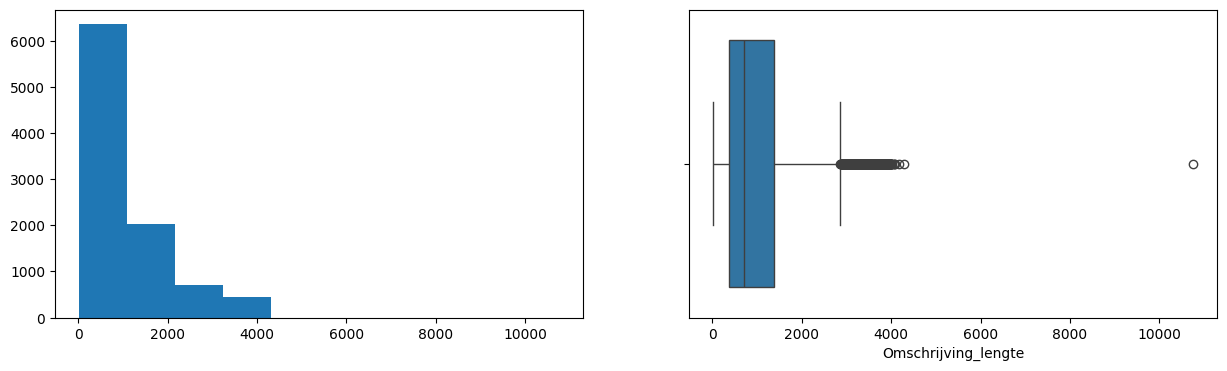

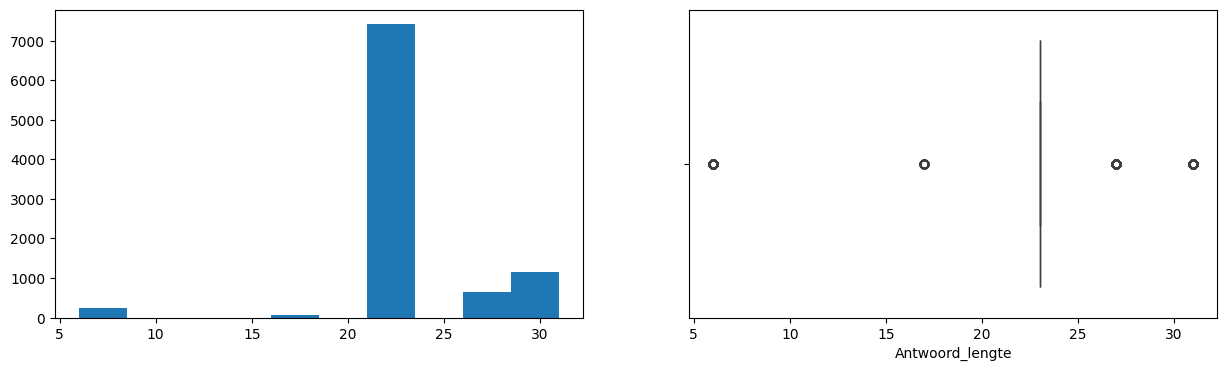

In [18]:
# bepaal numerieke variabelen
num_vars = train.drop(columns=['ID']).select_dtypes(include=np.number).columns.tolist()

# plot de verdeling van elke numerieke variabele in histogram en boxplot
for var in num_vars:
    plt.figure(figsize = (15, 4))
    plt.subplot(1, 2, 1)
    plt.hist(train[var])
    plt.subplot(1, 2, 2)
    sns.boxplot(x=train[var])
    plt.show()


In [19]:
train.select_dtypes(include="number").corr()

,ID,Omschrijving_lengte,Antwoord_lengte
ID,1.000000,0.005604,-0.001498
Omschrijving_lengte,0.005604,1.000000,-0.020285
Antwoord_lengte,-0.001498,-0.020285,1.000000


<Axes: >

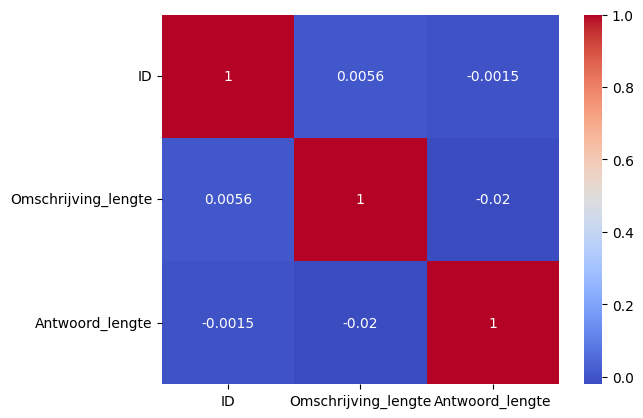

In [20]:
sns.heatmap(train.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")

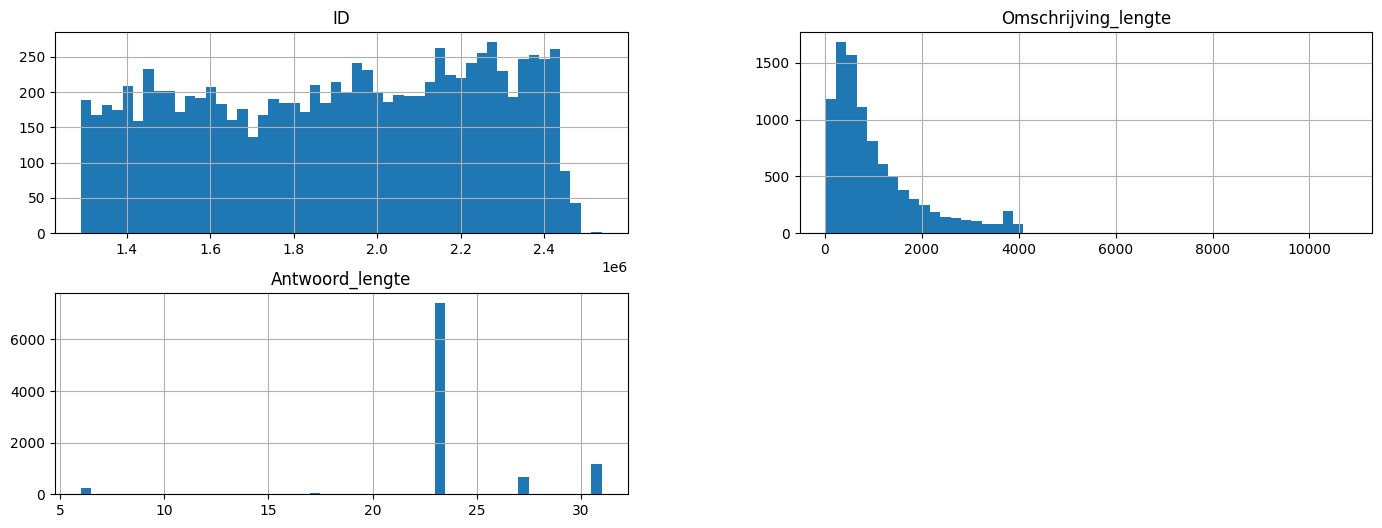

In [21]:
train.hist(bins=50, figsize=(17, 6))
plt.show()

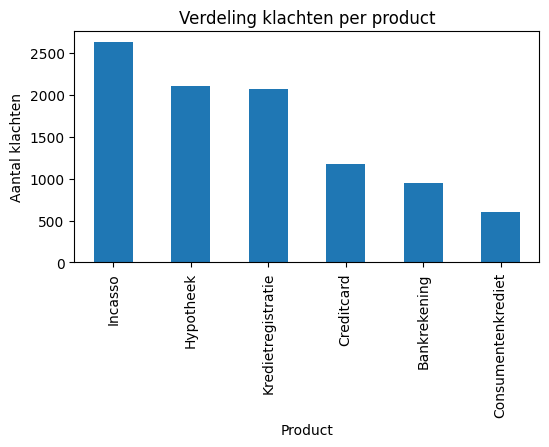

In [22]:
# Bar chart voor Product
plt.figure(figsize=(6,3))
train['Product'].value_counts().plot(kind="bar")
plt.title("Verdeling klachten per product")
plt.xlabel("Product")
plt.ylabel("Aantal klachten")
plt.show()

Incasso ontvangt de meeste klachten

### Analyse per product

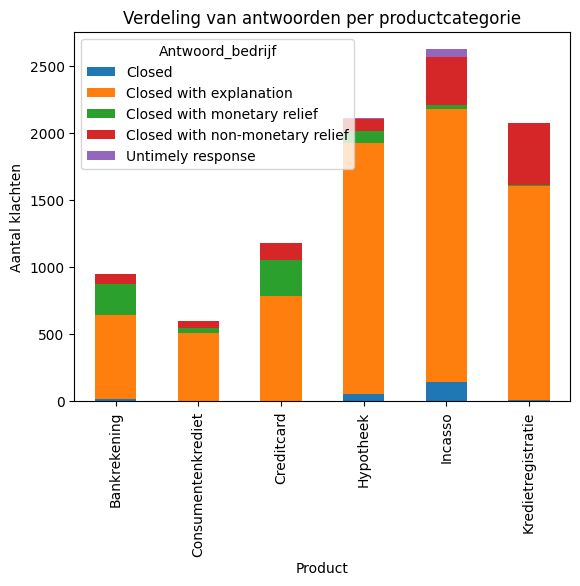

In [23]:
pd.crosstab(train["Product"], train["Antwoord_bedrijf"]).plot(kind="bar", stacked=True)
plt.title("Verdeling van antwoorden per productcategorie")
plt.ylabel("Aantal klachten")
plt.show()

### Analyse per specifieke feature

#### Wordcloud per categorie

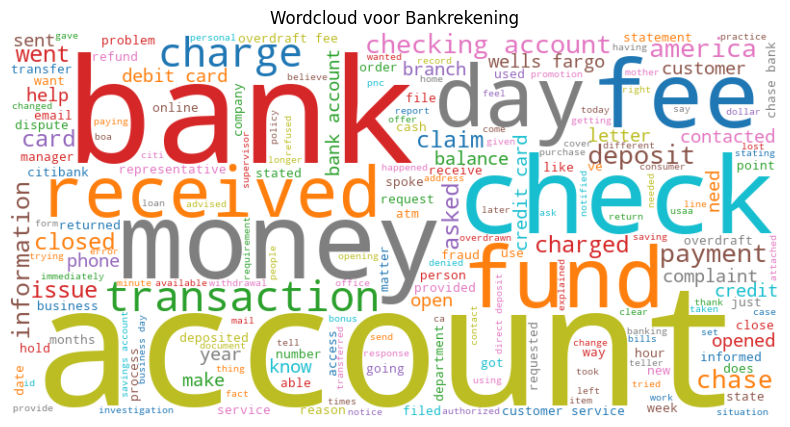

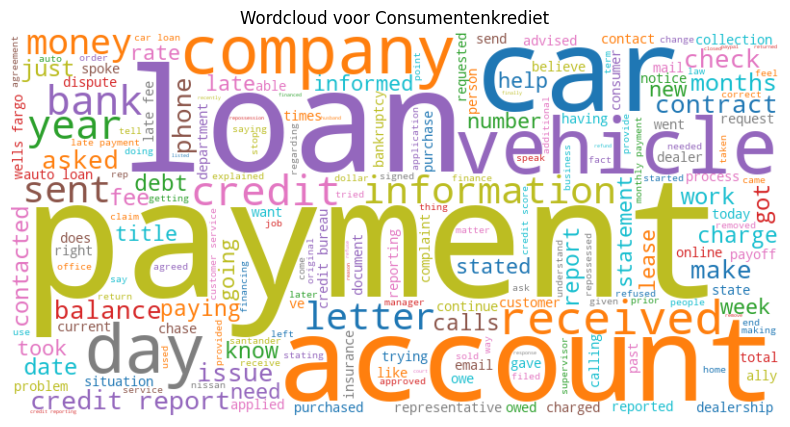

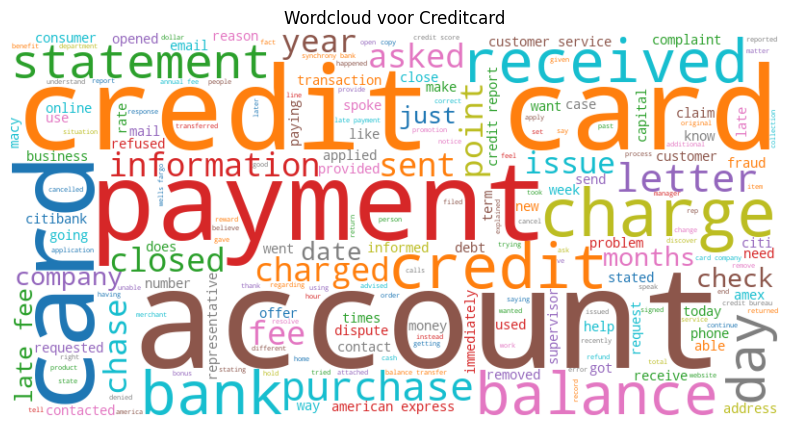

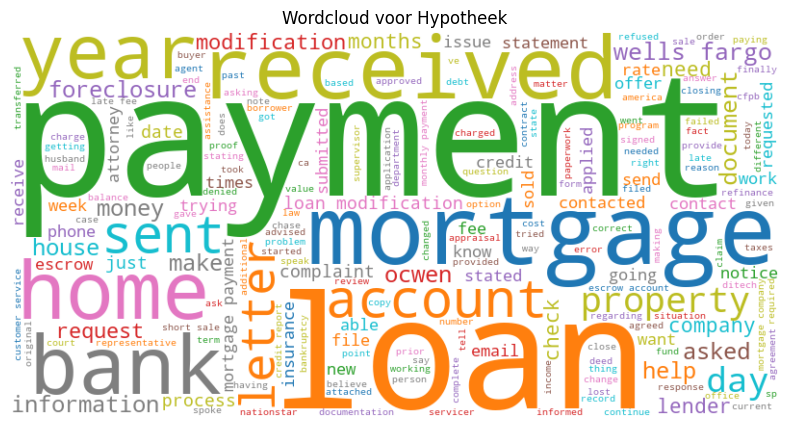

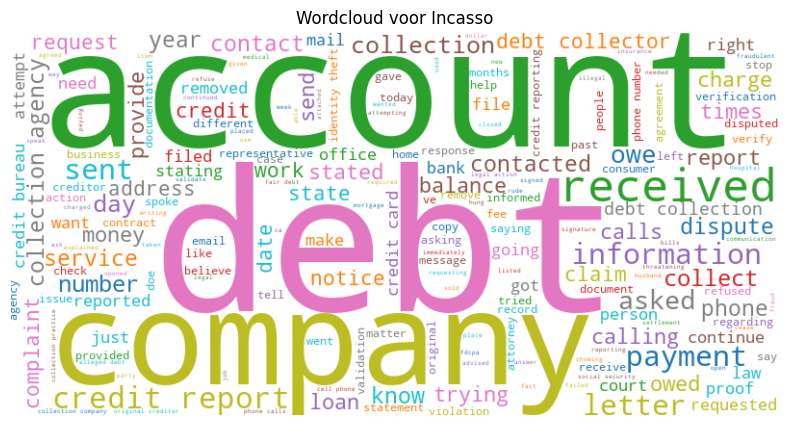

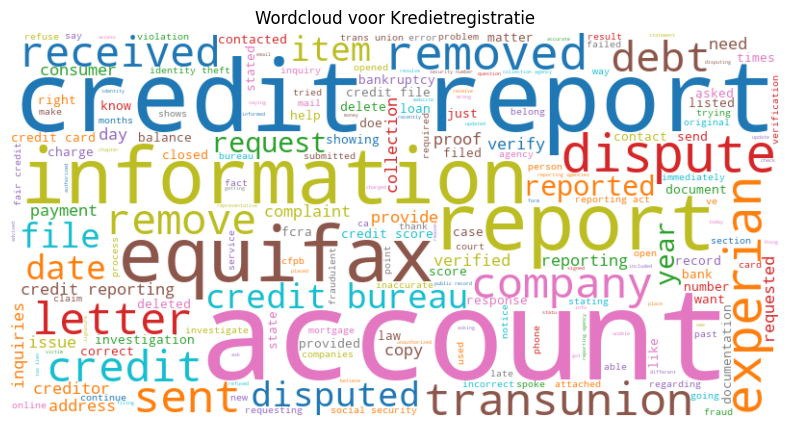

In [ ]:
stopwoorden = list(set(ENGLISH_STOP_WORDS).union({
    'xxxx', 'xx', 'xxx', 'did', 'please', 'told', 'paid', 'called', 'time', 'said', 'month', 'pay',
    'a','b','c','d','e','f','g','h','i','j','k','l','m','n', 'o','p','q','r','s','t','u','v','w','x','y','z'
}))
#stopwoorden2 = set(stopwords.words("english"))

train["clean"] = train["Omschrijving"].fillna("").str.lower().str.replace(r'[^a-z\s]', ' ', regex=True)

vectorizer = TfidfVectorizer(stop_words=stopwoorden, max_features=1000)
tfidf = vectorizer.fit_transform(train["clean"])
woorden = vectorizer.get_feature_names_out()

train["Top_keywords"] = [
    [woorden[i] for i in tfidf[row].toarray()[0].argsort()[-5:][::-1]]
    for row in range(tfidf.shape[0])
]

for product, groep in train.groupby("Product"):
    tekst = " ".join(groep["clean"])
    wc = WordCloud(width=800, height=400, background_color="white",
                   stopwords=set(stopwoorden), colormap="tab10").generate(tekst)
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Wordcloud voor {product}")
    plt.show()